# Bulgarian beaches × Copernicus High-Resolution Ocean Colour

Hyperlocal version (~100 m) of the per-beach water-quality analysis.

Uses the **`OCEANCOLOUR_BLK_BGC_HR_L3_NRT_009_206`** product — Sentinel-2 derived chlorophyll, turbidity, suspended matter and Secchi depth at ~100 m resolution.

Standalone — does not depend on the other notebook.

## Prereqs
```bash
pip install copernicusmarine xarray netcdf4 pandas matplotlib requests folium branca pillow
copernicusmarine login   # one-time
```

In [2]:
!pip install copernicusmarine xarray netcdf4 pandas matplotlib requests folium branca pillow

In [3]:
!copernicusmarine login

INFO - 2026-04-25T21:20:12Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
Copernicus Marine username: mr.greend233@gmail.com
Copernicus Marine password: 
INFO - 2026-04-25T21:20:50Z - Credentials file stored in /root/.copernicusmarine/.copernicusmarine-credentials.


In [4]:
import requests
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import copernicusmarine as cm
from datetime import datetime, timedelta

pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

## Step 1 — Pull all Bulgarian coastal bathing waters from EEA

In [5]:
EEA_URL = (
    'https://water.discomap.eea.europa.eu/arcgis/rest/services'
    '/BathingWater/BathingWater_Dyna_WM/MapServer/0/query'
)

params = {
    'where': "countryCode='BG' AND bwWaterCategory='Coastal'",
    'outFields': 'bathingWaterIdentifier,bathingWaterName,longitude,latitude,qualityStatus',
    'returnGeometry': 'false',
    'f': 'json',
}

resp = requests.get(EEA_URL, params=params, timeout=20)
resp.raise_for_status()
raw = resp.json()

beaches = pd.DataFrame([f['attributes'] for f in raw['features']])
beaches = beaches.rename(columns={
    'bathingWaterIdentifier': 'id',
    'bathingWaterName': 'name',
    'longitude': 'lon',
    'latitude': 'lat',
    'qualityStatus': 'eea_quality',
})
print(f'beaches: {len(beaches)}')

BG_BBOX = {
    'min_lon': float(beaches['lon'].min()) - 0.05,
    'max_lon': float(beaches['lon'].max()) + 0.05,
    'min_lat': float(beaches['lat'].min()) - 0.05,
    'max_lat': float(beaches['lat'].max()) + 0.05,
}
print('bbox:', BG_BBOX)
beaches.head()

beaches: 92
bbox: {'min_lon': 27.4333, 'max_lon': 28.6403, 'min_lat': 41.9733, 'max_lat': 43.7767}


,id,name,lon,lat,eea_quality
0,BG3310104426003018,КАМЧИЯ-ПЛАЖ РОМАНТИКА,27.8889,43.0392,Excellent
1,BG3310507598003022,БЯЛА-ПЛАЖ ЧАЙКА,27.8981,42.8542,Excellent
2,BG3310610135003006,СВ.СВ. КОНСТАНТИН И ЕЛЕНА-ГОЛЯМ ПЛАЖ,28.0153,43.2325,Excellent
3,BG3310610135003016,ХИЖА ЧЕРНОМОРЕЦ,27.9286,43.1186,Excellent
4,BG3320302508008016,БАЛЧИК-ДВОРЕЦА,28.1464,43.4028,Excellent


## Step 2 — Discover the HR Ocean Colour dataset IDs

In [6]:
hr_info = cm.describe(product_id='OCEANCOLOUR_BLK_BGC_HR_L3_NRT_009_206')
for product in hr_info.products:
    for ds in product.datasets:
        print(ds.dataset_id)

Fetching catalogue 1:  50%|█████     | 1/2 [00:02<00:02,  2.27s/it]

cmems_obs-oc_blk_bgc-optics_nrt_l3-hr-mosaic_P1D-m
cmems_obs_oc_blk_bgc_geophy_nrt_l3-hr_P1D-m
cmems_obs_oc_blk_bgc_optics_nrt_l3-hr_P1D-m
cmems_obs_oc_blk_bgc_transp_nrt_l3-hr_P1D-m
cmems_obs_oc_blk_bgc_tur-spm-chl_nrt_l3-hr-mosaic_P1D-m


## Step 3 — Open the three sub-datasets (chl, transparency, optics)

**If Step 2 prints different IDs, edit the constants below to match.**

INFO - 2026-04-25T22:26:58Z - Selected dataset version: "202107"
INFO:copernicusmarine:Selected dataset version: "202107"
INFO - 2026-04-25T22:26:58Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
INFO - 2026-04-25T22:26:59Z - Listing files on remote server...
INFO:copernicusmarine:Listing files on remote server...
3it [00:02,  1.27it/s]
INFO - 2026-04-25T22:27:02Z - Total size of the download: 8.94 MB.
INFO:copernicusmarine:Total size of the download: 8.94 MB.
INFO - 2026-04-25T22:27:08Z - Selected dataset version: "202107"
INFO:copernicusmarine:Selected dataset version: "202107"
INFO - 2026-04-25T22:27:08Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
INFO - 2026-04-25T22:27:08Z - Listing files on remote server...
INFO:copernicusmarine:Listing files on remote server...
3it [00:02,  1.36it/s]
INFO - 2026-04-25T22:27:11Z - Total size of the download: 16.19 MB.
INFO:copernicusmarine:Total size of the 

files: 7


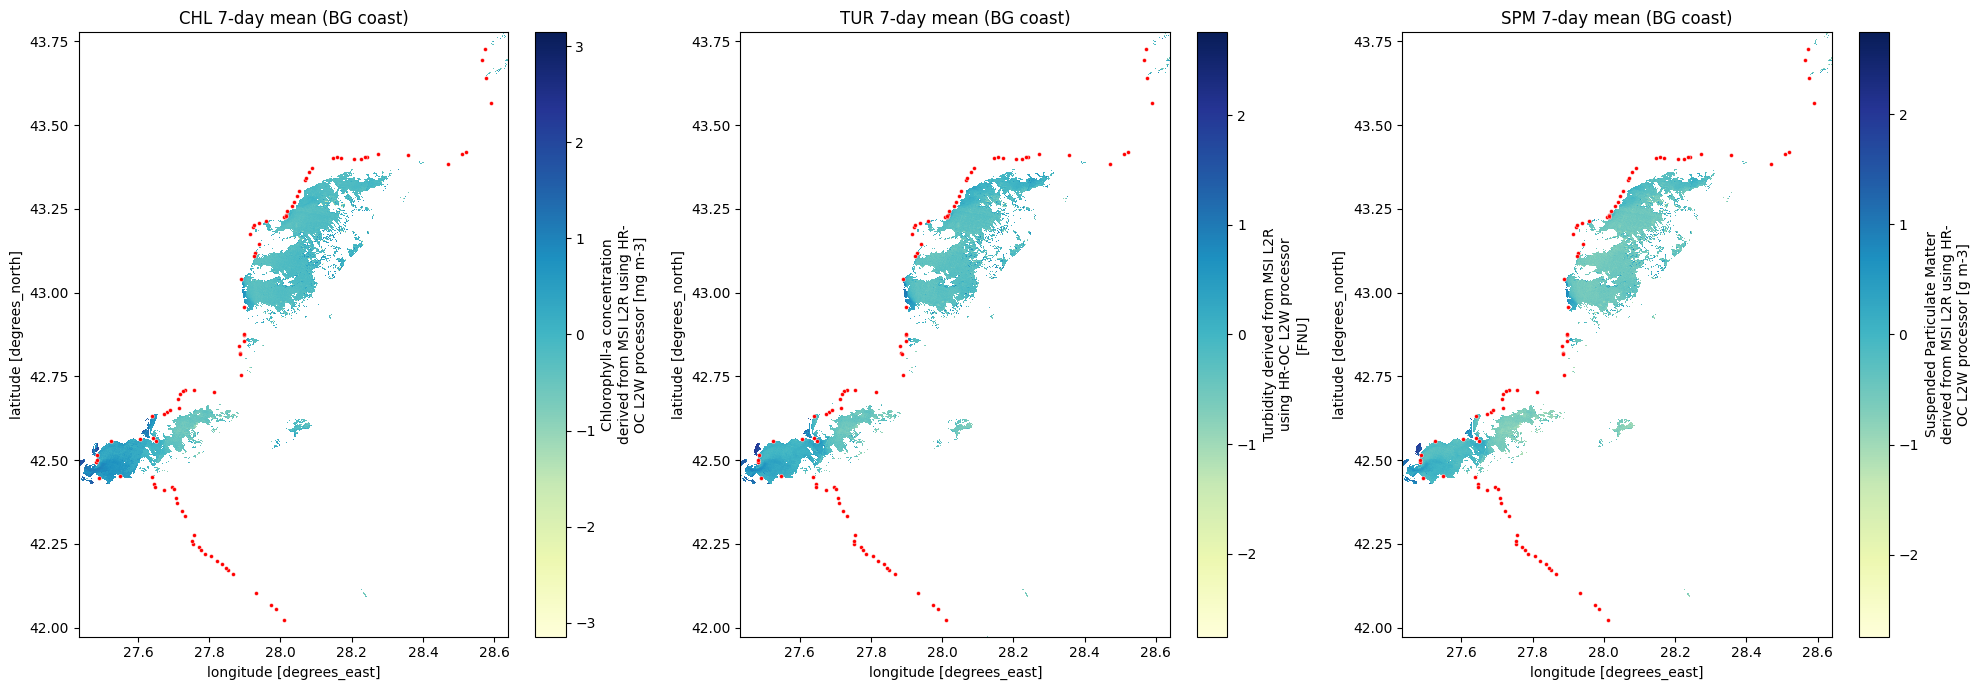

In [17]:
# Pull last 7 days, build a multi-day cloud-free composite
for d in [20260424, 20260423, 20260422, 20260421, 20260420, 20260419, 20260418]:
    cm.get(
        dataset_id=DS_HR_MOSAIC,
        dataset_version='202107',
        output_directory='hr_data/week',
        no_directories=True,
        filter=f'*{d}_P1D*',
    )

import glob
files = sorted(glob.glob('hr_data/week/*.nc'))
print('files:', len(files))

# Open all together and take the mean over time (skipping NaN)
ds_week = xr.open_mfdataset(files, combine='by_coords')
bg_week = ds_week.sel(
    lon=slice(BG_BBOX['min_lon'], BG_BBOX['max_lon']),
    lat=slice(BG_BBOX['max_lat'], BG_BBOX['min_lat']),
)

# 7-day cloud-free composite per variable
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, var in zip(axes, ['CHL', 'TUR', 'SPM']):
    composite = bg_week[var].mean(dim='time', skipna=True)
    np.log10(composite.where(composite > 0)).plot(ax=ax, cmap='YlGnBu')
    ax.scatter(beaches['lon'], beaches['lat'], s=8, c='red', edgecolor='white', linewidth=0.3)
    ax.set_title(f'{var} 7-day mean (BG coast)')
plt.tight_layout(); plt.show()

## Step 4 — Print the full BG coast: what does the HR data actually look like?

Four panels covering the entire BG coast for the latest day. Red dots = beaches. White = clouds or land.

/tmp/ipykernel_66325/4235946167.py:5: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  end = datetime.utcnow().date()


Pulling dates: ['20260425', '20260424', '20260423', '20260422', '20260421', '20260420', '20260419']


INFO - 2026-04-25T22:31:48Z - Selected dataset version: "202107"
INFO:copernicusmarine:Selected dataset version: "202107"
INFO - 2026-04-25T22:31:48Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
INFO - 2026-04-25T22:31:49Z - Listing files on remote server...
INFO:copernicusmarine:Listing files on remote server...
3it [00:02,  1.22it/s]
INFO - 2026-04-25T22:31:53Z - Total size of the download: 0.00 B.
INFO:copernicusmarine:Total size of the download: 0.00 B.
INFO - 2026-04-25T22:31:53Z - No data to download
INFO:copernicusmarine:No data to download
INFO - 2026-04-25T22:31:56Z - Selected dataset version: "202107"
INFO:copernicusmarine:Selected dataset version: "202107"
INFO - 2026-04-25T22:31:56Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
INFO - 2026-04-25T22:31:57Z - Listing files on remote server...
INFO:copernicusmarine:Listing files on remote server...
3it [00:02,  1.30it/s]
INFO - 2026-04-25T

13 files downloaded


/tmp/ipykernel_66325/4235946167.py:28: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print('weekly bg shape:', dict(bg_week.dims))


weekly bg shape: {'time': 7, 'lat': 1948, 'lon': 912}


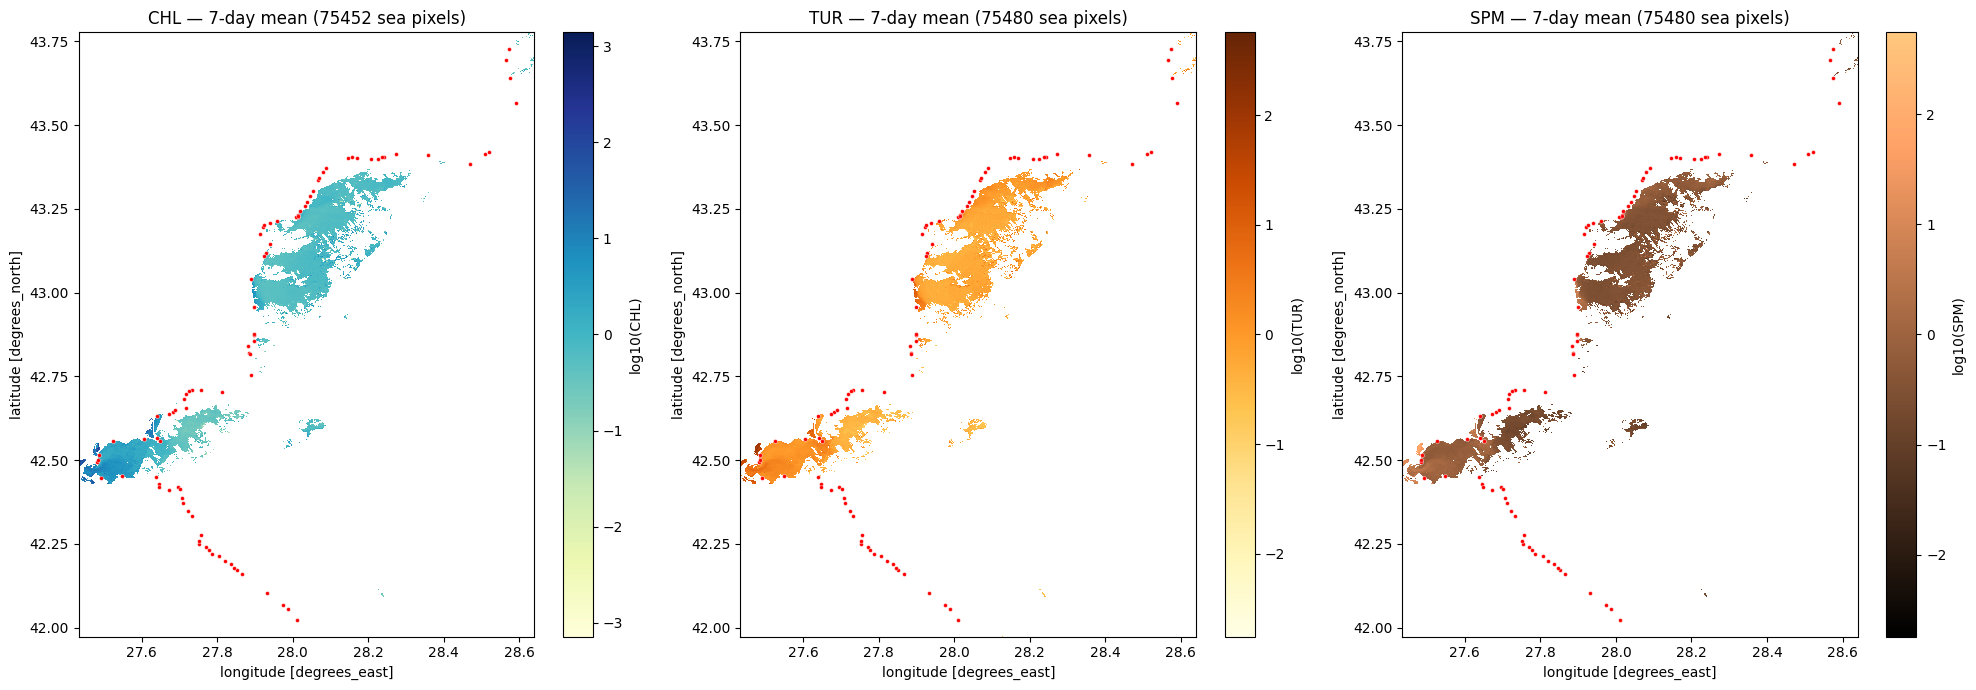

In [19]:
import os, glob

DAYS_BACK = 7   # tweak: 7 = good compromise; 14 = more coverage, slower

end = datetime.utcnow().date()
date_strs = [(end - timedelta(days=i)).strftime('%Y%m%d') for i in range(DAYS_BACK)]
print('Pulling dates:', date_strs)

os.makedirs('hr_data/week', exist_ok=True)
for d in date_strs:
    cm.get(
        dataset_id=DS_HR_MOSAIC,
        dataset_version='202107',
        output_directory='hr_data/week',
        no_directories=True,
        filter=f'*{d}_P1D*',
    )

files = sorted(glob.glob('hr_data/week/*.nc'))
print(f'{len(files)} files downloaded')

# Open all days together and slice to BG bbox
ds_week = xr.open_mfdataset(files, combine='by_coords')
bg_week = ds_week.sel(
    lon=slice(BG_BBOX['min_lon'], BG_BBOX['max_lon']),
    lat=slice(BG_BBOX['max_lat'], BG_BBOX['min_lat']),
)
print('weekly bg shape:', dict(bg_week.dims))

# Plot 7-day cloud-free composite for each variable
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, (var, cmap) in zip(axes, [('CHL','YlGnBu'),('TUR','YlOrBr'),('SPM','copper')]):
    composite = bg_week[var].mean(dim='time', skipna=True)
    np.log10(composite.where(composite > 0)).plot(
        ax=ax, cmap=cmap, cbar_kwargs={'label': f'log10({var})'}
    )
    ax.scatter(beaches['lon'], beaches['lat'], s=8, c='red', edgecolor='white', linewidth=0.3)
    n_obs = int(np.isfinite(composite.values).sum())
    ax.set_title(f'{var} — {DAYS_BACK}-day mean ({n_obs} sea pixels)')
plt.tight_layout(); plt.show()

СВ.СВ. КОНСТАНТИН И ЕЛЕНА-ГОЛЯМ ПЛАЖ 43.2325 28.0153


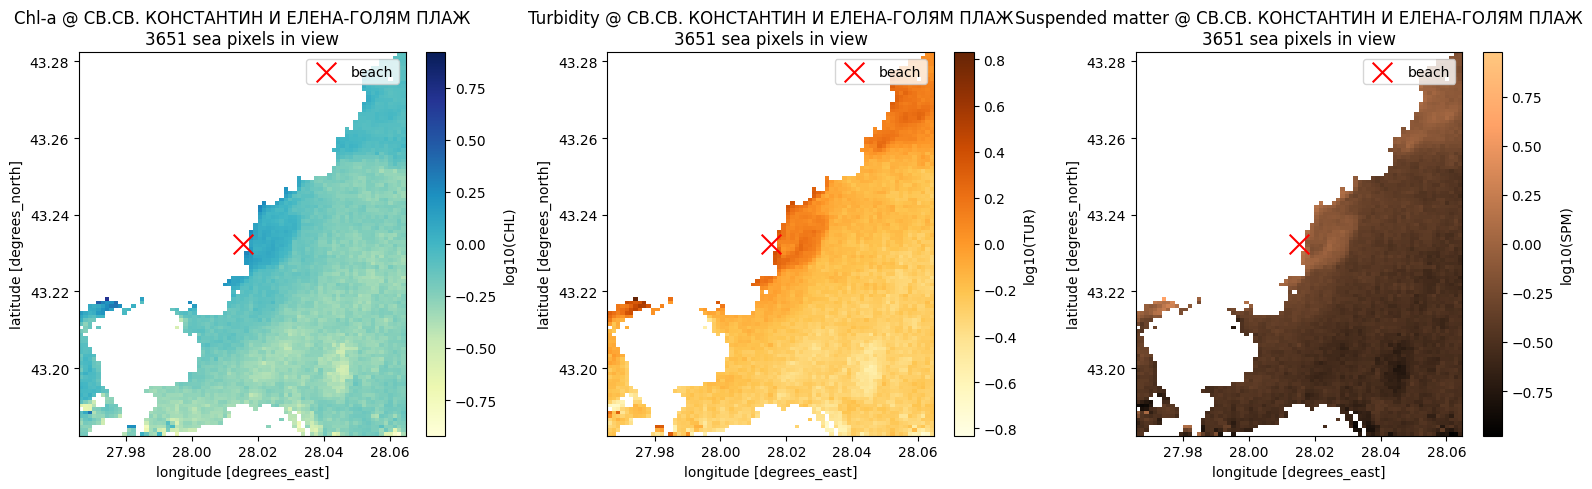

In [32]:
beach = beaches.iloc[2]   # change index to inspect different beaches
print(beach['name'], beach['lat'], beach['lon'])

zoom = 0.05  # ~5 km box

# Use bg_week (multi-day composite) instead of single-day ds
zoom_panels = [
    ('CHL', 'Chl-a', 'YlGnBu'),
    ('TUR', 'Turbidity', 'YlOrBr'),
    ('SPM', 'Suspended matter', 'copper'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (var, title, cmap) in zip(axes, zoom_panels):
    if var not in bg_week.data_vars:
        ax.set_title(f'{var} not available'); continue
    # 7-day mean over time, then zoom to beach
    da = bg_week[var].mean(dim='time', skipna=True).sel(
        lon=slice(beach['lon'] - zoom, beach['lon'] + zoom),
        lat=slice(beach['lat'] + zoom, beach['lat'] - zoom),  # lat descends in this product
    )
    plot_data = np.log10(da.where(da > 0))
    plot_data.plot(ax=ax, cmap=cmap, cbar_kwargs={'label': f'log10({var})'})
    ax.scatter(beach['lon'], beach['lat'], c='red', marker='x', s=200, label='beach')
    n_pix = int(np.isfinite(da.values).sum())
    ax.set_title(f"{title} @ {beach['name']}\n{n_pix} sea pixels in view")
    ax.legend()
plt.tight_layout(); plt.show()

## Step 6 — Per-beach extraction helper

Averages all sea pixels in a small box around each beach. At 100 m resolution one beach covers multiple pixels — averaging is more robust than picking a single one.

In [40]:
def hr_box_stats(ds, var, lat, lon, radius_deg=0.03):
    """
    Average sea pixels in a small box around (lat, lon) over the time window.
    Returns (time series of spatial means, n_sea_pixels_in_box).
    """
    if var not in ds.data_vars:
        return None, 0

    da = ds[var]

    # Lat axis usually descends in these HR files — order the slice high-to-low if so
    lat_vals = da['lat'].values
    if lat_vals[0] > lat_vals[-1]:
        lat_slice = slice(lat + radius_deg, lat - radius_deg)
    else:
        lat_slice = slice(lat - radius_deg, lat + radius_deg)

    box = da.sel(lon=slice(lon - radius_deg, lon + radius_deg), lat=lat_slice)
    if box.size == 0:
        return None, 0

    # Mean across the spatial box -> 1D time series
    series = box.mean(dim=['lat', 'lon'], skipna=True).to_pandas()

    # How many sea pixels exist anywhere in the box across all time steps
    other_axes = tuple(box.dims.index(d) for d in box.dims if d not in ('lat', 'lon'))
    if other_axes:
        sea_mask = np.isfinite(box.values).any(axis=other_axes)
    else:
        sea_mask = np.isfinite(box.values)
    n_sea = int(sea_mask.sum())
    return series, n_sea

sea pixels in box: 1226
count    1.000000
mean     0.724356
std           NaN
min      0.724356
25%      0.724356
50%      0.724356
75%      0.724356
max      0.724356
Name: CHL, dtype: float64


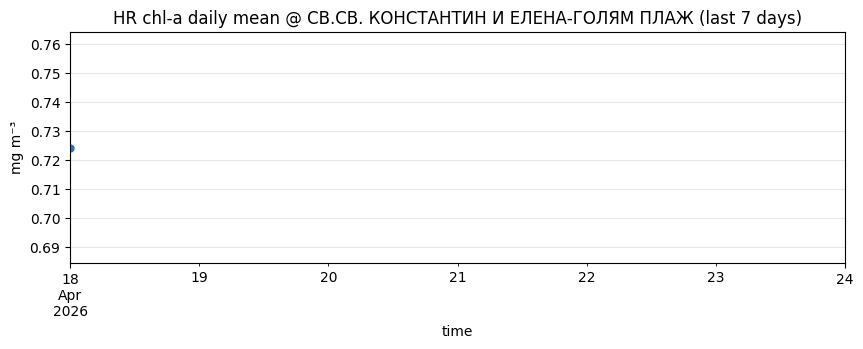

In [41]:
# Quick check on the chosen beach using the multi-day composite
chl_series, n_pix = hr_box_stats(bg_week, 'CHL', beach['lat'], beach['lon'])
print(f"sea pixels in box: {n_pix}")

if chl_series is None or chl_series.dropna().empty:
    # Try a wider box if the tight one is all land/cloud
    chl_series, n_pix = hr_box_stats(bg_week, 'CHL', beach['lat'], beach['lon'], radius_deg=0.01)
    print(f"after widening: {n_pix} sea pixels")

if chl_series is not None and chl_series.notna().any():
    print(chl_series.describe())
    fig, ax = plt.subplots(figsize=(10, 3))
    chl_series.plot(ax=ax, marker='o', ms=5)
    ax.set_title(f"HR chl-a daily mean @ {beach['name']} (last {DAYS_BACK} days)")
    ax.set_ylabel('mg m⁻³'); ax.grid(alpha=0.3)
    plt.show()
else:
    print('Still no data — beach is in a coastal nook with no Sentinel-2 hits this week.')

## Step 7 — Loop over all 92 beaches

In [47]:
hr_rows = []
for _, b in beaches.iterrows():
    chl, n_chl = hr_box_stats(bg_week, 'CHL', b['lat'], b['lon'])
    if chl is None or chl.dropna().empty:
        chl, n_chl = hr_box_stats(bg_week, 'CHL', b['lat'], b['lon'], radius_deg=0.005)
    if chl is None or chl.dropna().empty:
        chl, n_chl = hr_box_stats(bg_week, 'CHL', b['lat'], b['lon'], radius_deg=0.01)

    tur, _ = hr_box_stats(bg_week, 'TUR', b['lat'], b['lon'], radius_deg=0.01)
    spm, _ = hr_box_stats(bg_week, 'SPM', b['lat'], b['lon'], radius_deg=0.01)

    if chl is None or chl.dropna().empty:
        hr_rows.append({
            'id': b['id'], 'name': b['name'], 'lat': b['lat'], 'lon': b['lon'],
            'eea_quality': b['eea_quality'], 'error': 'no-sea-pixels-or-cloudy',
        })
        continue

    hr_rows.append({
        'id': b['id'], 'name': b['name'],
        'lat': b['lat'], 'lon': b['lon'],
        'eea_quality': b['eea_quality'],
        'n_sea_pixels':  n_chl,
        'n_obs_days':    int(np.isfinite(chl.values).sum()),
        'chl_mean':      float(chl.mean(skipna=True)),
        'chl_max':       float(chl.max(skipna=True)),
        'tur_mean':      float(tur.mean(skipna=True)) if tur is not None else None,
        'spm_mean':      float(spm.mean(skipna=True)) if spm is not None else None,
    })

hr = pd.DataFrame(hr_rows)
print(f"beaches with data: {hr['chl_mean'].notna().sum()} / {len(hr)}")
print(f"beaches with no data: {hr['chl_mean'].isna().sum()}")
hr.head(15)

beaches with data: 51 / 92
beaches with no data: 41


,id,name,lat,lon,eea_quality,n_sea_pixels,n_obs_days,chl_mean,chl_max,tur_mean,spm_mean,error
0,BG3310104426003018,КАМЧИЯ-ПЛАЖ РОМАНТИКА,43.0392,27.8889,Excellent,871.0,1.0,1.146587,1.146587,2.486968,1.462314,NaN
1,BG3310507598003022,БЯЛА-ПЛАЖ ЧАЙКА,42.8542,27.8981,Excellent,255.0,1.0,1.014657,1.014657,3.955930,2.327168,NaN
2,BG3310610135003006,СВ.СВ. КОНСТАНТИН И ЕЛЕНА-ГОЛЯМ ПЛАЖ,43.2325,28.0153,Excellent,1226.0,1.0,0.724356,0.724356,1.368770,0.800159,NaN
3,BG3310610135003016,ХИЖА ЧЕРНОМОРЕЦ,43.1186,27.9286,Excellent,635.0,1.0,0.556208,0.556208,0.726990,0.424328,NaN
4,BG3320302508008016,БАЛЧИК-ДВОРЕЦА,43.4028,28.1464,Excellent,NaN,NaN,NaN,NaN,NaN,NaN,no-sea-pixels-or-cloudy
5,BG3320353120008019,АЛБЕНА,43.3600,28.0803,Excellent,NaN,NaN,NaN,NaN,NaN,NaN,no-sea-pixels-or-cloudy
6,BG3321707257008007,БОЛАТА,43.3825,28.4706,Excellent,NaN,NaN,NaN,NaN,NaN,NaN,no-sea-pixels-or-cloudy
7,BG3320302508008012,ТУЗЛАТА,43.3997,28.2250,Good,1.0,1.0,0.193196,0.193196,NaN,NaN,NaN
8,BG3410407079002018,БУРГАС-ПЛАЖ ЧЕРНОМОРСКИ СОЛНИЦИ,42.5144,27.4861,Excellent,1650.0,3.0,44.804501,121.018082,25.868296,17.734882,NaN
9,BG3411344094002037,ЛОЗЕНЕЦ-ЦЕНТРАЛЕН ПЛАЖ,42.2125,27.8056,Excellent,NaN,NaN,NaN,NaN,NaN,NaN,no-sea-pixels-or-cloudy


In [50]:
def score_hr(row):
    if pd.isna(row.get('chl_mean')):
        return pd.Series({'flag_chl': None, 'flag_tur': None, 'overall': 'unknown'})
    f = {}
    f['flag_chl'] = 'red' if row['chl_mean'] > 5 else 'amber' if row['chl_mean'] > 2 else 'green'
    f['flag_tur'] = 'red' if (row['tur_mean'] or 0) > 5 else 'amber' if (row['tur_mean'] or 0) > 2 else 'green'
    f['overall'] = 'red' if 'red' in f.values() else 'amber' if 'amber' in f.values() else 'green'
    return pd.Series(f)

hr = hr.join(hr.apply(score_hr, axis=1))
hr.to_csv('bg_beaches_hr.csv', index=False)

print('saved', hr.shape, '→ bg_beaches_hr.csv')
print('\nflag distribution:')
print(hr['overall'].value_counts())
print('\nworst chl:')
print(hr.nlargest(10, 'chl_mean')[['name','chl_mean','tur_mean','overall','eea_quality']])

saved (92, 15) → bg_beaches_hr.csv

flag distribution:
overall
unknown    41
green      38
amber      10
red         3
Name: count, dtype: int64

worst chl:
                               name   chl_mean   tur_mean overall eea_quality
8   БУРГАС-ПЛАЖ ЧЕРНОМОРСКИ СОЛНИЦИ  44.804501  25.868296     red   Excellent
61              БУРГАС-СЕВЕРЕН ПЛАЖ   5.992714   1.384037     red   Excellent
25            БУРГАС-ЦЕНТРАЛЕН ПЛАЖ   5.579839   1.427861     red   Excellent
45     КВ. КРАЙМОРИЕ-ЦЕНТРАЛЕН ПЛАЖ   4.856597   1.375600   amber   Excellent
75           ПОМОРИЕ-ЦЕНТРАЛЕН ПЛАЖ   4.138680   3.684910   amber   Excellent
14             ПОМОРИЕ-ИЗТОЧЕН ПЛАЖ   4.043070   2.632807   amber   Excellent
51                   КЪМПИНГ АХЕЛОЙ   4.011264   1.945409   amber   Excellent
62               ПЛАЖ РОСЕНЕЦ-СЕВЕР   2.801092   1.426799   amber   Excellent
52                ПОМОРИЕ-ЮЖЕН ПЛАЖ   2.701580   1.204226   amber   Excellent
50                   РАВДА-ПЛАЖ НДК   2.441588        NaN   amb

## Step 8 — Score & save

/tmp/ipykernel_66325/2817106702.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mcm.get_cmap('YlGnBu')



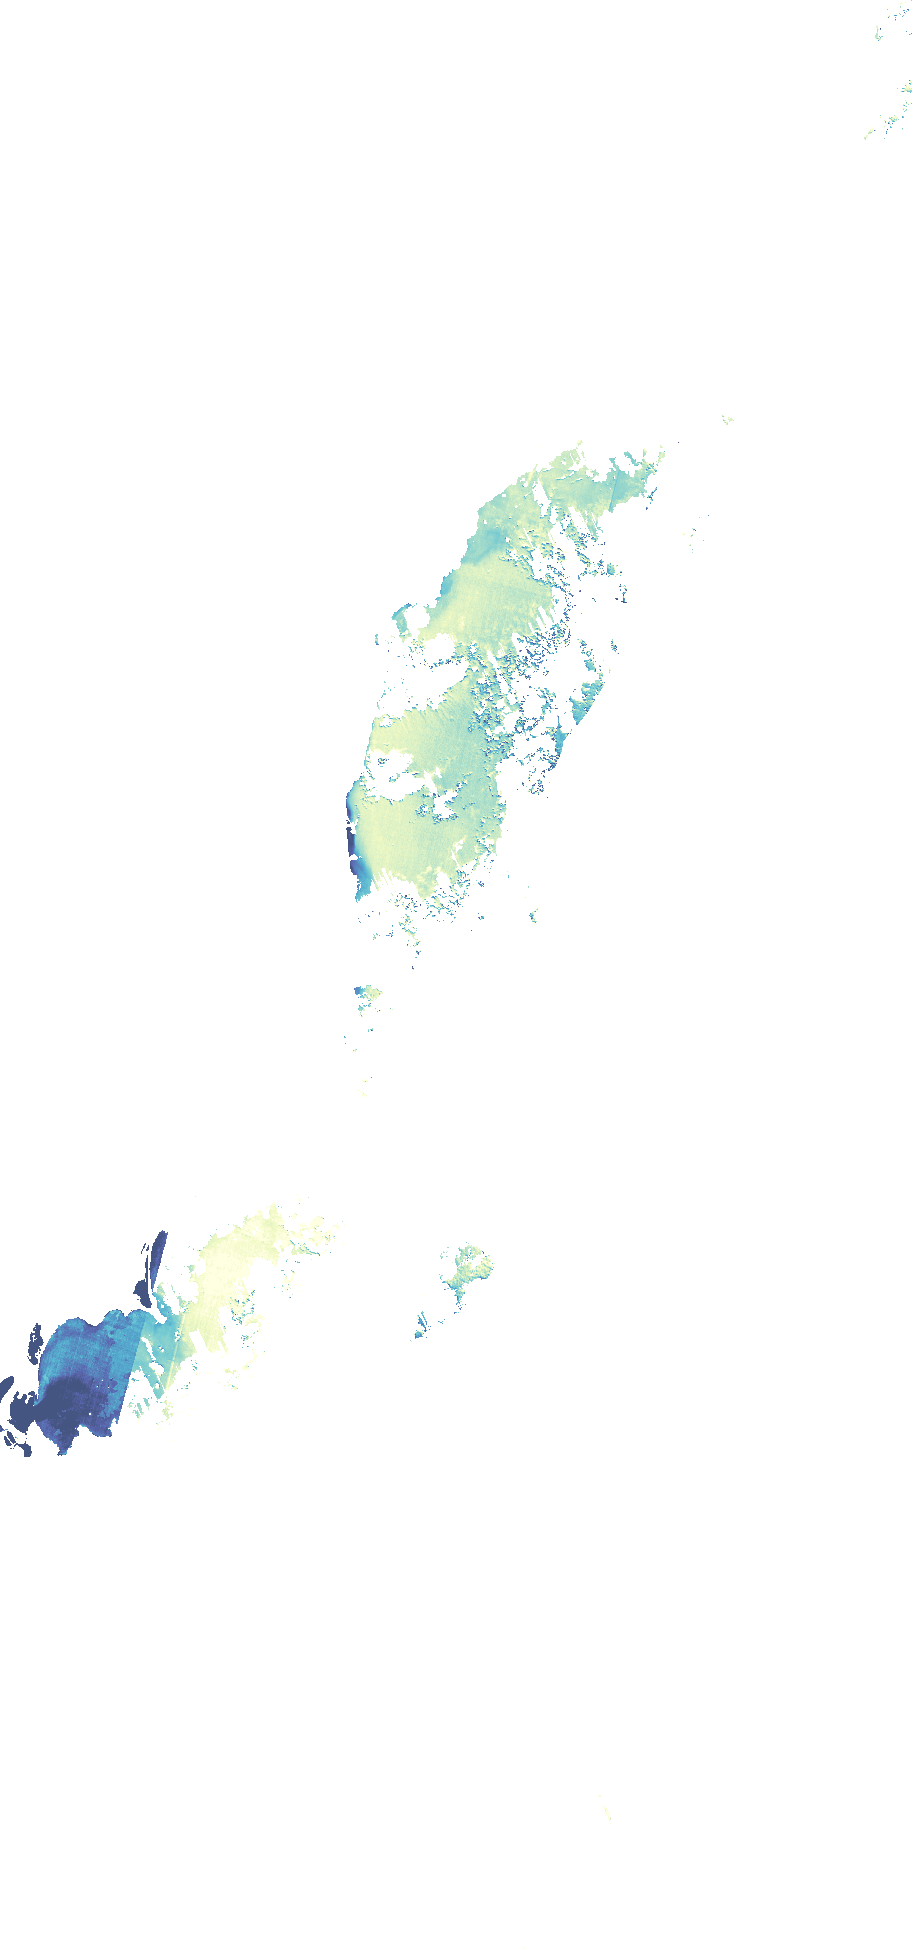

In [51]:
import folium
from folium.raster_layers import ImageOverlay
from branca.colormap import linear
from matplotlib import cm as mcm
from matplotlib.colors import Normalize
import io, base64
from PIL import Image

# 1) 7-day composite chl slice (lat x lon)
chl_grid = bg_week['CHL'].mean(dim='time', skipna=True)
chl_grid = chl_grid.transpose('lat', 'lon')
arr = chl_grid.values

# Log-scale visualization (chl spans orders of magnitude)
arr_log = np.log10(np.where(arr > 0, arr, np.nan))

# 2) Build coloured RGBA PNG with NaN -> transparent
finite = np.isfinite(arr_log)
if not finite.any():
    raise RuntimeError('No valid CHL pixels in BG bbox — increase DAYS_BACK in Step 4')
vmin, vmax = np.nanpercentile(arr_log[finite], [5, 95])
norm = Normalize(vmin=vmin, vmax=vmax, clip=True)
cmap = mcm.get_cmap('YlGnBu')
rgba = cmap(norm(arr_log))
rgba[..., 3] = np.where(finite, 0.75, 0.0)

# Flip vertically if lat is descending so north-up matches folium
lats = chl_grid['lat'].values
lons = chl_grid['lon'].values
if lats[0] > lats[-1]:
    img_arr = (rgba * 255).astype(np.uint8)        # already north-up
else:
    img_arr = (rgba[::-1] * 255).astype(np.uint8)  # flip

buf = io.BytesIO()
Image.fromarray(img_arr).save(buf, format='PNG')
data_url = 'data:image/png;base64,' + base64.b64encode(buf.getvalue()).decode()

bounds = [[float(lats.min()), float(lons.min())],
          [float(lats.max()), float(lons.max())]]

# 3) Folium map with satellite basemap
m = folium.Map(
    location=[float(beaches['lat'].mean()), float(beaches['lon'].mean())],
    zoom_start=8, tiles=None,
)
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri World Imagery', name='Satellite', overlay=False, control=True,
).add_to(m)

ImageOverlay(
    image=data_url, bounds=bounds, opacity=0.75,
    name=f'Chl-a {DAYS_BACK}-day mean (~100 m, log scale)',
).add_to(m)

# Color bar with real (un-logged) values for readability
colormap = linear.YlGnBu_09.scale(10**vmin, 10**vmax)
colormap.caption = f'Chl-a (mg m⁻³) — Sentinel-2 ~100 m, last {DAYS_BACK}d mean'
colormap.add_to(m)

# 4) Beach markers coloured by overall flag
flag_color = {'green': 'green', 'amber': 'orange', 'red': 'red', 'unknown': 'gray'}
for _, b in hr.iterrows():
    flag = b.get('overall', 'unknown') or 'unknown'
    if pd.notna(b.get('chl_mean')):
        popup = (
            f"<b>{b['name']}</b><br>"
            f"EEA: {b.get('eea_quality')}<br>"
            f"Chl mean: {b['chl_mean']:.2f} mg m⁻³<br>"
            f"Turbidity: {b.get('tur_mean')}<br>"
            f"SPM: {b.get('spm_mean')}<br>"
            f"Sea pixels: {b.get('n_sea_pixels')}<br>"
            f"Obs days: {b.get('n_obs_days')}<br>"
            f"Overall: <b>{flag}</b>"
        )
    else:
        popup = f"<b>{b['name']}</b><br>{b.get('error', 'no data')}"
    folium.CircleMarker(
        location=[b['lat'], b['lon']], radius=5,
        color=flag_color.get(flag, 'gray'), fill=True, fill_opacity=0.9,
        popup=folium.Popup(popup, max_width=260),
    ).add_to(m)

folium.LayerControl().add_to(m)
m

## Step 9 — Folium satellite map with 100 m chl heatmap overlay

In [48]:
# Final step: per-beach summary report

# Sort beaches by overall flag (worst first), then by chl
flag_order = {'red': 0, 'amber': 1, 'green': 2, 'unknown': 3}
hr_sorted = hr.copy()
hr_sorted['_sort'] = hr_sorted['overall'].map(flag_order)
hr_sorted = hr_sorted.sort_values(['_sort', 'chl_mean'], ascending=[True, False]).drop(columns='_sort')

# Pretty-print summary for each beach
print(f"{'='*100}")
print(f"BG COAST WATER QUALITY REPORT — last {DAYS_BACK} days, ~100m Sentinel-2 data")
print(f"{'='*100}\n")

for _, b in hr_sorted.iterrows():
    flag = b.get('overall', 'unknown') or 'unknown'
    flag_emoji = {'red': '[RED]', 'amber': '[AMBER]', 'green': '[GREEN]', 'unknown': '[--]'}[flag]

    print(f"{flag_emoji} {b['name']}")
    print(f"   coords:        ({b['lat']:.4f}, {b['lon']:.4f})")
    print(f"   eea_official:  {b.get('eea_quality', 'n/a')}")

    if pd.notna(b.get('chl_mean')):
        print(f"   chl mean:      {b['chl_mean']:.3f} mg/m³   (max: {b.get('chl_max', float('nan')):.3f})")
        print(f"   turbidity:     {b['tur_mean']:.3f} FNU" if pd.notna(b.get('tur_mean')) else "   turbidity:     n/a")
        print(f"   suspended:     {b['spm_mean']:.3f} g/m³" if pd.notna(b.get('spm_mean')) else "   suspended:     n/a")
        print(f"   sea pixels:    {int(b['n_sea_pixels'])}   |   obs days: {int(b['n_obs_days'])}/{DAYS_BACK}")
        print(f"   flags:         chl={b.get('flag_chl')}, tur={b.get('flag_tur')}  →  OVERALL: {flag.upper()}")
    else:
        print(f"   ERROR: {b.get('error', 'no data')}")
    print()

# Aggregate stats
print(f"{'='*100}")
print(f"SUMMARY")
print(f"{'='*100}")
print(f"Total beaches:                 {len(hr)}")
print(f"With Sentinel-2 data:          {hr['chl_mean'].notna().sum()}")
print(f"No data (cloudy/small bay):    {hr['chl_mean'].isna().sum()}")
print(f"\nFlag distribution:")
print(hr['overall'].value_counts().to_string())
print(f"\nChl-a stats (mg/m³):")
print(hr[['chl_mean','chl_max']].describe().to_string())

# Compact CSV-style table to copy-paste
print(f"\n{'='*100}")
print(f"COMPACT TABLE")
print(f"{'='*100}")
cols = ['name', 'eea_quality', 'chl_mean', 'tur_mean', 'spm_mean', 'n_obs_days', 'overall']
print(hr_sorted[cols].to_string(index=False))

KeyError: 'overall'

## Debugging notes

- **`DatasetNotFound`** in Step 3 → re-read Step 2 output and update the `DS_HR_*` constants.
- **`var not in ds.data_vars`** → variable name varies (`CHL` vs `chl`, `TUR` vs `turbidity`). Check `print(list(ds_hr_optics.data_vars))` and adjust.
- **All NaN at a beach** → cloudy days only OR small bay with no sea pixels in the box. The loop already retries with a larger radius; expand further if needed.
- **Sparse `n_obs_days`** → Sentinel-2 has 5-day revisit + cloud loss. Over 30 days expect 3–6 observations per beach. For trends use 60–90 day windows.
- **Heatmap looks blocky** → that *is* the 100 m grid. Zoom in on the folium map to see bay-level structure.
